# Imports and load data

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders_revenue = pd.read_csv("../data/processed/orders_revenue.csv", parse_dates=[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])

# Load customers to get the real unique customer identifier
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

# Join to get customer_unique_id
orders_revenue = orders_revenue.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

print(f"Orders loaded: {len(orders_revenue):,}")
print(f"\nWith customer_id:        {orders_revenue['customer_id'].nunique():,} unique")
print(f"With customer_unique_id: {orders_revenue['customer_unique_id'].nunique():,} unique")

Orders loaded: 96,470

With customer_id:        96,470 unique
With customer_unique_id: 93,350 unique


# Check what we're working with

In [35]:
print("Date range:")
print("  From:", orders_revenue["order_purchase_timestamp"].min())
print("  To:  ", orders_revenue["order_purchase_timestamp"].max())

print(f"\nUnique customers: {orders_revenue['customer_id'].nunique():,}")
print(f"Unique orders:    {orders_revenue['order_id'].nunique():,}")
print(f"Total revenue:    R$ {orders_revenue['revenue'].sum():,.2f}")

Date range:
  From: 2016-09-15 12:16:38
  To:   2018-08-29 15:00:37

Unique customers: 96,470
Unique orders:    96,470
Total revenue:    R$ 15,421,082.85


# Define the snapshot date

In [36]:
snapshot_date = orders_revenue["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print(f"Snapshot date: {snapshot_date}")

Snapshot date: 2018-08-30 15:00:37


# Compute RFM values

In [37]:
rfm = orders_revenue.groupby("customer_unique_id").agg(
    last_purchase = ("order_purchase_timestamp", "max"),
    frequency     = ("order_id", "count"),
    monetary      = ("revenue", "sum")
).reset_index()

rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days
rfm = rfm.drop(columns=["last_purchase"])

print(f"RFM table shape: {rfm.shape}")
print(f"\nFrequency distribution:")
print(rfm["frequency"].value_counts().head(10))

RFM table shape: (93350, 4)

Frequency distribution:
frequency
1     90549
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


# Explore the RFM distributions

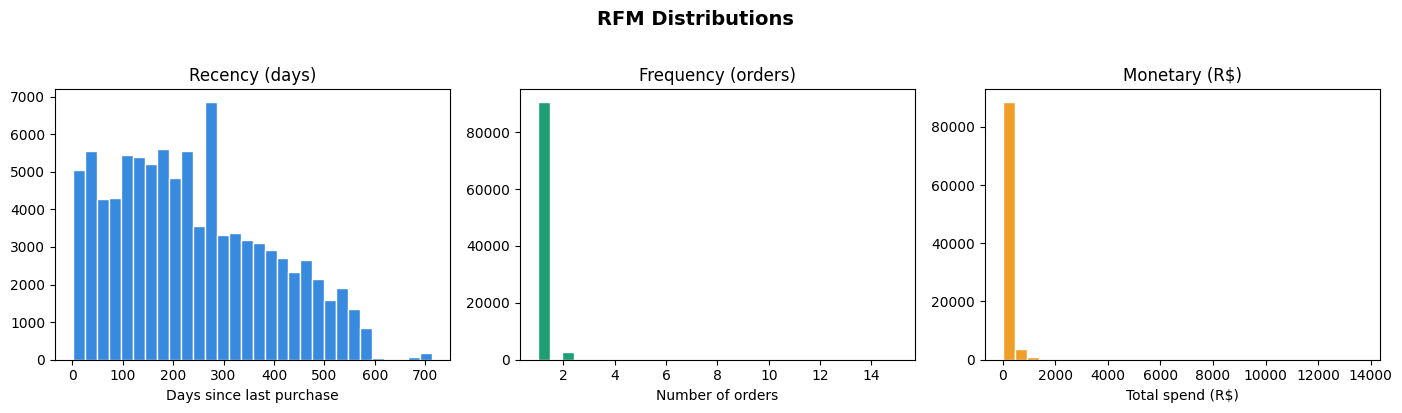

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rfm["recency"],   bins=30, color="#378ADD", edgecolor="white")
axes[0].set_title("Recency (days)")
axes[0].set_xlabel("Days since last purchase")

axes[1].hist(rfm["frequency"], bins=30, color="#1D9E75", edgecolor="white")
axes[1].set_title("Frequency (orders)")
axes[1].set_xlabel("Number of orders")

axes[2].hist(rfm["monetary"],  bins=30, color="#EF9F27", edgecolor="white")
axes[2].set_title("Monetary (R$)")
axes[2].set_xlabel("Total spend (R$)")

plt.suptitle("RFM Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/03_rfm_distributions.png", dpi=150)
plt.show()

# Score each customer 1 to 5

In [39]:
rfm["r_score"] = pd.qcut(rfm["recency"],  5, labels=[5, 4, 3, 2, 1], duplicates="drop")
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5], duplicates="drop")
rfm["m_score"] = pd.qcut(rfm["monetary"].rank(method="first"),  5, labels=[1, 2, 3, 4, 5], duplicates="drop")

# Convert to integer
rfm["r_score"] = rfm["r_score"].astype(int)
rfm["f_score"] = rfm["f_score"].astype(int)
rfm["m_score"] = rfm["m_score"].astype(int)

print("Scores added ✓")
print(rfm[["customer_unique_id", "recency", "frequency", "monetary", "r_score", "f_score", "m_score"]].head(10))

Scores added ✓
                 customer_unique_id  recency  frequency  monetary  r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76        4   

   f_score  m_score  
0        1        4  
1        1        1  
2        1        2  
3        1        1  
4        1      

# Assign segment labels

In [40]:
def assign_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif f >= 4 and m >= 3:
        return "Loyal"
    elif r >= 4 and f == 1:
        return "New Customers"
    elif r >= 3 and f <= 3:
        return "Potential Loyalist"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r == 1 and f == 1:
        return "Lost"
    else:
        return "Other"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

print("Segment distribution:")
print(rfm["segment"].value_counts())

Segment distribution:
segment
Potential Loyalist    26121
Other                 19653
Loyal                 16439
At Risk               13339
New Customers          7477
Champions              6494
Lost                   3827
Name: count, dtype: int64


# Segment summary table

In [41]:
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customers     = ("customer_unique_id", "count"),
        avg_recency   = ("recency",   "mean"),
        avg_frequency = ("frequency", "mean"),
        avg_monetary  = ("monetary",  "mean"),
        total_revenue = ("monetary",  "sum")
    )
    .reset_index()
)

segment_summary["revenue_share_%"] = (
    segment_summary["total_revenue"] / segment_summary["total_revenue"].sum() * 100
).round(1)

segment_summary["customer_share_%"] = (
    segment_summary["customers"] / segment_summary["customers"].sum() * 100
).round(1)

segment_summary = segment_summary.sort_values("total_revenue", ascending=False)

pd.set_option("display.float_format", "{:,.2f}".format)
print(segment_summary.to_string(index=False))

           segment  customers  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_share_%  customer_share_%
Potential Loyalist      26121       145.81           1.00        159.48   4,165,746.77            27.00             28.00
             Loyal      16439       291.51           1.11        217.00   3,567,307.50            23.10             17.60
             Other      19653       267.58           1.01        116.67   2,292,820.83            14.90             21.10
         Champions       6494        91.12           1.18        312.09   2,026,717.60            13.10              7.00
           At Risk      13339       394.71           1.01        114.77   1,530,937.35             9.90             14.30
     New Customers       7477        91.21           1.00        163.48   1,222,312.31             7.90              8.00
              Lost       3827       474.08           1.00        160.76     615,240.49             4.00              4.10


# Segment revenue chart

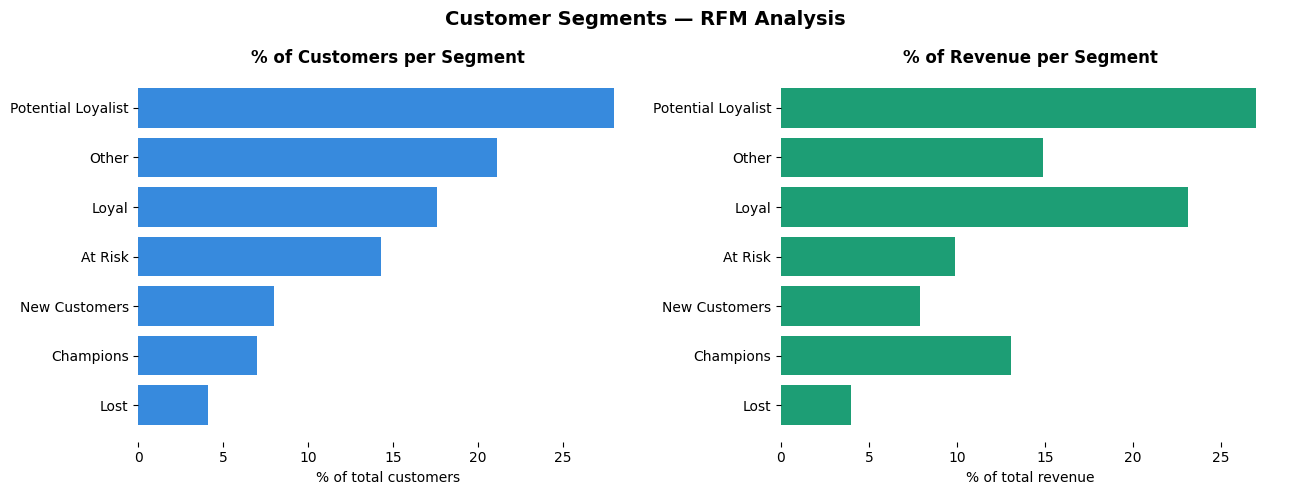

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

seg = segment_summary.sort_values("customers")

# Customer share
ax1.barh(seg["segment"], seg["customer_share_%"], color="#378ADD")
ax1.set_title("% of Customers per Segment", fontweight="bold")
ax1.set_xlabel("% of total customers")

# Revenue share
ax2.barh(seg["segment"], seg["revenue_share_%"], color="#1D9E75")
ax2.set_title("% of Revenue per Segment", fontweight="bold")
ax2.set_xlabel("% of total revenue")

for ax in [ax1, ax2]:
    sns.despine(ax=ax, left=True, bottom=True)

plt.suptitle("Customer Segments — RFM Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/03_segment_comparison.png", dpi=150)
plt.show()

# Save the results

In [43]:
rfm.to_csv("../data/processed/rfm_segmented.csv", index=False)
segment_summary.to_csv("../data/processed/segment_summary.csv", index=False)

print("Saved ✓")
print(f"\n=== KEY FINDINGS ===")
print(f"Total customers analysed: {len(rfm):,}")
print(f"\nTop segment by revenue:")
top = segment_summary.iloc[0]
print(f"  '{top['segment']}' = {top['customer_share_%']:.1f}% of customers, {top['revenue_share_%']:.1f}% of revenue")
print(f"\nHypothesis: A minority of customers drive the majority of revenue")
champions = segment_summary[segment_summary["segment"] == "Champions"]
if len(champions) > 0:
    c = champions.iloc[0]
    print(f"Result: Champions = {c['customer_share_%']:.1f}% of customers, {c['revenue_share_%']:.1f}% of revenue")

Saved ✓

=== KEY FINDINGS ===
Total customers analysed: 93,350

Top segment by revenue:
  'Potential Loyalist' = 28.0% of customers, 27.0% of revenue

Hypothesis: A minority of customers drive the majority of revenue
Result: Champions = 7.0% of customers, 13.1% of revenue
